In [2]:
import os
import glob
import json
import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp
from scipy.interpolate import RegularGridInterpolator

from skimage.feature import canny
from scipy.interpolate import UnivariateSpline, interp1d

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [3]:
def upsampling_smooting(orig_response, eval_arrx, eval_arry, y_min, y_max, x_min, x_max,
                         sigma_x = 25, sigma_y = 25,  resolution = 500):

    # Upsampling the response map to 500 points

    high_res_y = np.linspace(y_min, y_max, resolution)
    high_res_x = np.linspace(x_min, x_max, resolution)

    fit_points = [eval_arry, eval_arrx]
    interp = RegularGridInterpolator(fit_points, orig_response, bounds_error = False, fill_value = -np.inf)

    eval_y_high, eval_x_high = np.meshgrid(high_res_y, high_res_x, indexing='ij')

    interp_points = np.array([eval_y_high.ravel(), eval_x_high.ravel()]).T

    response_node_01_high = interp(interp_points, method='slinear').reshape(resolution, resolution)
    response_node_01_high = lyapunov_threshold(response_node_01_high, 0.000)

    # Smoothing the response map to have continuous boundary by applying gaussian filter
    sigma = [sigma_y, sigma_x]
    smoothed_node_01_high = sp.ndimage.filters.gaussian_filter(response_node_01_high, sigma, mode='nearest')
    smoothed_node_01_high = lyapunov_threshold(smoothed_node_01_high, 0.000)

    return high_res_y, high_res_x, smoothed_node_01_high

In [4]:
def boundary_detection(response_map, y_arr, x_arr):
    # edge detection using Canny Edge Detector
    edge_coord = canny(response_map)
    y_coord, x_coord = np.where(edge_coord == 1)

    y_edges = y_arr[y_coord]
    x_edges = x_arr[x_coord]

    # sorting the values
    x_order_ind = np.argsort(x_edges)
    x_edges_sort = x_edges[x_order_ind]
    y_edges_sort = y_edges[x_order_ind]

    # interpolating the points to find the boundary
    function = interp1d(x_edges_sort, y_edges_sort, kind = 'nearest', fill_value='extrapolate')
    
    return function, x_edges_sort, y_edges_sort

In [5]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
n_trials = 5

# time vector
T = params['T'] = 5000
time_ = np.arange(0, T)
t_start = 500
t_end = T

In [6]:
# setting the variables
k_values = np.arange(-1, 1, 0.2)

sige_min = 2.5; sige_max = 17.5; sige_steps = 100
sigi_min = 2.5; sigi_max = 17.5; sigi_steps = 100

eval_sigma_e = sige_min + np.arange(0, sige_steps) / sige_steps * (sige_max - sige_min)
eval_sigma_i = sigi_min + np.arange(0, sigi_steps) / sigi_steps * (sigi_max - sigi_min)

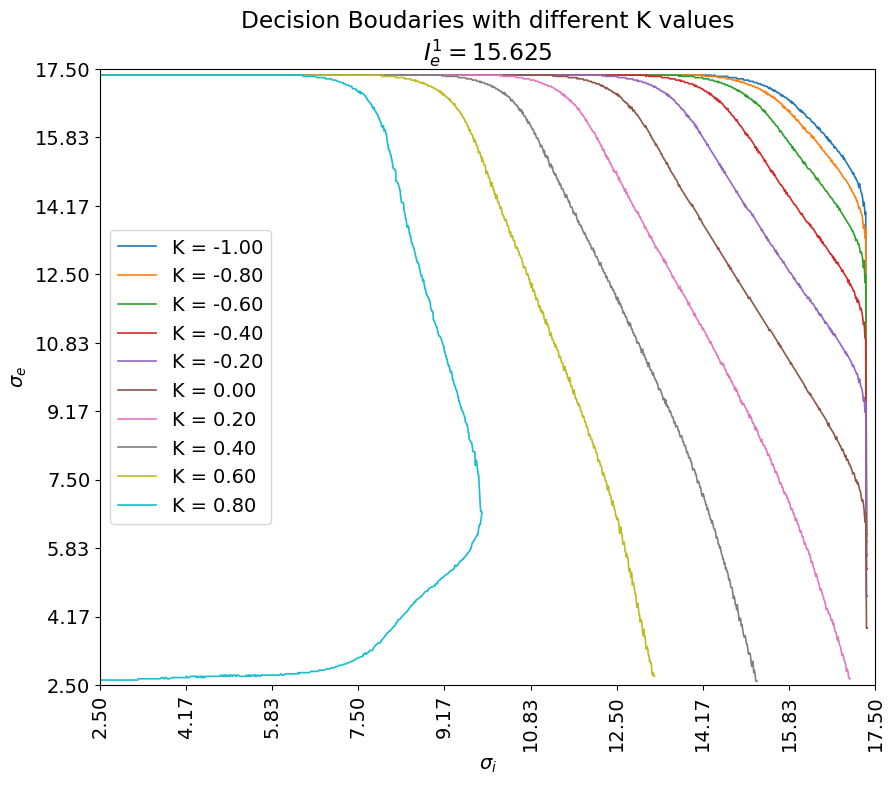

In [7]:
save_str = datetime.datetime(2023, 12, 10)
results_dict = os.path.join('./sv_coupled_model_m', f"exp-{save_str.year}-{save_str.month}-{save_str.day}", 's_02')

file_paths = glob.glob(os.path.join(results_dict, "*.pkl"))
num_files = len(file_paths)

K_vals = []

if num_files == 0:
    print('no files found!')

else:
    for nf, path in enumerate(file_paths):
        basename = os.path.basename(path).split('.pkl')[0]
        K = float(basename.split('K_')[-1].split('_ie')[0])

        if K == -0.00:
            K = 0.0
        K_vals.append(K)
    
    K_vals = np.array(K_vals)

    order_ind = np.argsort(K_vals)
    K_vals = K_vals[order_ind]
    file_paths = np.array(file_paths)[order_ind]

    plt.figure(figsize=(10,8))
    for nf, path in enumerate(file_paths):
        basename = os.path.basename(path).split('.pkl')[0]
        I = float(basename.split('ie_')[-1])

        lyap_results = pickle.load(open(path, 'rb'))

        orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.001)

        sige_arr, sigi_arr, response_map = upsampling_smooting(orig_response, eval_sigma_i, eval_sigma_e, 
                                                       y_min = 2.5, y_max = 17.5, x_min = 2.5, x_max = 17.5, 
                                                       sigma_x = 25, sigma_y = 25,  resolution = 500)
        
        edge_boundary, sigi_edges, sige_edges = boundary_detection(response_map, sige_arr, sigi_arr)

        plot_x = np.linspace(min(sigi_edges), max(sigi_edges), 1000)
        plot_y = edge_boundary(plot_x)

        if K_vals[nf] == 0.8:
            y_val_max_x = plot_y[-1]
            y_upper_ind = np.where(plot_y >= y_val_max_x)[0]
            y_lower_ind = np.where(plot_y < y_val_max_x)[0]
            y_plot_upper = plot_y[y_upper_ind]
            y_plot_lower = plot_y[y_lower_ind]

            plot_y = np.array(list(y_plot_lower) + list(y_plot_upper)[::-1])
            plot_x = np.array(list(plot_x[y_lower_ind]) + list(plot_x[y_upper_ind])[::-1])

        plt.plot(plot_x, plot_y, linewidth = 1.2, label = f"K = {K_vals[nf]:.2f}")
    
    plt.xlabel(r"$\sigma_i$"); plt.ylabel(r"$\sigma_e$")
    plt.xticks(np.linspace(2.5, 17.5, 10), rotation = 90); plt.yticks(np.linspace(2.5, 17.5, 10))
    plt.xlim(2.5, 17.5); plt.ylim(2.5, 17.5)
    plt.title("Decision Boudaries with different K values\n" + r"$I^1_e = $" + f"{I:.3f}")
    plt.legend(loc = 'center left')


In [8]:
num_files

10

In [20]:
# Create the dataset
dataset = {
            "K": [],
            "sigma_i": [],
            "sigma_e": [],
            "stability": []
}

for k in range(num_files):
    lyap_results = pickle.load(open(file_paths[k], 'rb'))
    orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.000)

    for se in range(100):
        for si in range(100):
            dataset["K"].append(K_vals[k])
            dataset["sigma_i"].append(eval_sigma_i[si])
            dataset["sigma_e"].append(eval_sigma_e[se])
            dataset["stability"].append(orig_response[se, si])

In [21]:
import pandas as pd 

dataset_df = pd.DataFrame(dataset, columns=['K', 'sigma_i', 'sigma_e', 'stability'])
dataset_df.head(5)

,K,sigma_i,sigma_e,stability
0,-1.0,2.50,2.5,1.0
1,-1.0,2.65,2.5,1.0
2,-1.0,2.80,2.5,1.0
3,-1.0,2.95,2.5,1.0
4,-1.0,3.10,2.5,1.0


### Dimensional Reduction

In [22]:
from sklearn.manifold import TSNE

feat_cols = ['K', 'sigma_i', 'sigma_e']

df_subset = dataset_df.copy()

data_subset = df_subset[feat_cols].values

tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(data_subset)

df_subset['tsne-2d-one'] = tsne_results[:, 0]
df_subset['tsne-2d-two'] = tsne_results[:, 1]

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 100000 samples in 0.028s...
[t-SNE] Computed neighbors for 100000 samples in 1.301s...
[t-SNE] Computed conditional probabilities for sample 1000 / 100000
[t-SNE] Computed conditional probabilities for sample 2000 / 100000
[t-SNE] Computed conditional probabilities for sample 3000 / 100000
[t-SNE] Computed conditional probabilities for sample 4000 / 100000
[t-SNE] Computed conditional probabilities for sample 5000 / 100000
[t-SNE] Computed conditional probabilities for sample 6000 / 100000
[t-SNE] Computed conditional probabilities for sample 7000 / 100000
[t-SNE] Computed conditional probabilities for sample 8000 / 100000
[t-SNE] Computed conditional probabilities for sample 9000 / 100000
[t-SNE] Computed conditional probabilities for sample 10000 / 100000
[t-SNE] Computed conditional probabilities for sample 11000 / 100000
[t-SNE] Computed conditional probabilities for sample 12000 / 100000
[t-SNE] Computed conditional probab

<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

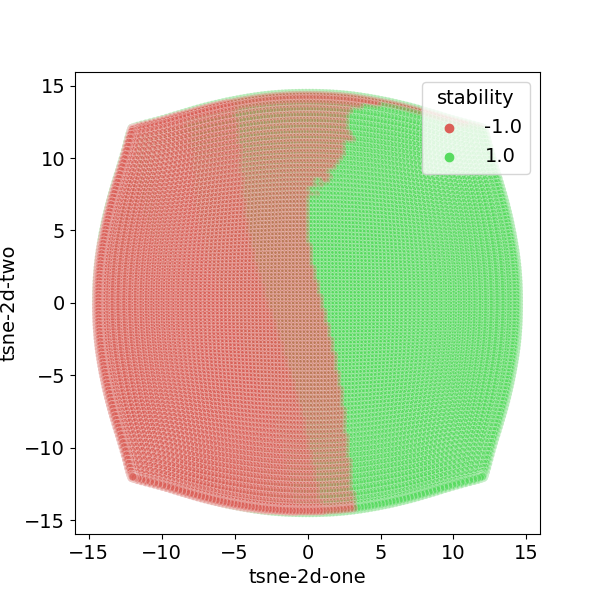

In [25]:
import seaborn as sns 

plt.figure(figsize=(6,6))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="stability",
    palette=sns.color_palette("hls", 3),
    data=df_subset,
    legend="full",
    alpha=0.3)

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

feature_1, feature_2 = np.meshgrid(k_val, sig_val) 
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T

tree = DecisionTreeClassifier().fit(dataset_df.iloc[:, :2], dataset_df['class'])
y_pred = np.reshape(tree.predict(grid), feature_1.shape)

display = DecisionBoundaryDisplay(xx0=feature_2, xx1=feature_1, response=y_pred)
display.plot()

In [ ]:
import glob

save_str = datetime.datetime(2023, 11, 23)
results_dict = os.path.join('./sv_coupled_model_m', f"exp-{save_str.year}-{save_str.month}-{save_str.day}", 's_02')

pkl_files = sorted(glob.glob(os.path.join(results_dict, '*.pkl')))
print(pkl_files)

dataset2 = np.zeros((len(pkl_files) * 200 * 200, 4))
row_num = 0

sig_val = np.linspace(2.5, 17.5, 200)

for path_ in pkl_files:
    
    with open(path_, 'rb') as f:
        lyap_results = pickle.load(f)
    
    k_ = float(os.path.basename(pkl_files[0]).split('_')[2])
    print(k_)
    region_1 = lyap_results['n1_mean']
    region_1_thresh = lyapunov_threshold(region_1, 0.01)

    for se in range(200):
        for si in range(200):
            dataset2[row_num, 0] = k_
            dataset2[row_num, 1] = sig_val[se]
            dataset2[row_num, 2] = sig_val[si]
            dataset2[row_num, 3] = region_1_thresh[se, si]

            row_num += 1

In [ ]:
dataset_df = pd.DataFrame(dataset2, columns=['K', 'sige', 'sigi', 'lyap'])
dataset_df

-1.0
0.0
1.0


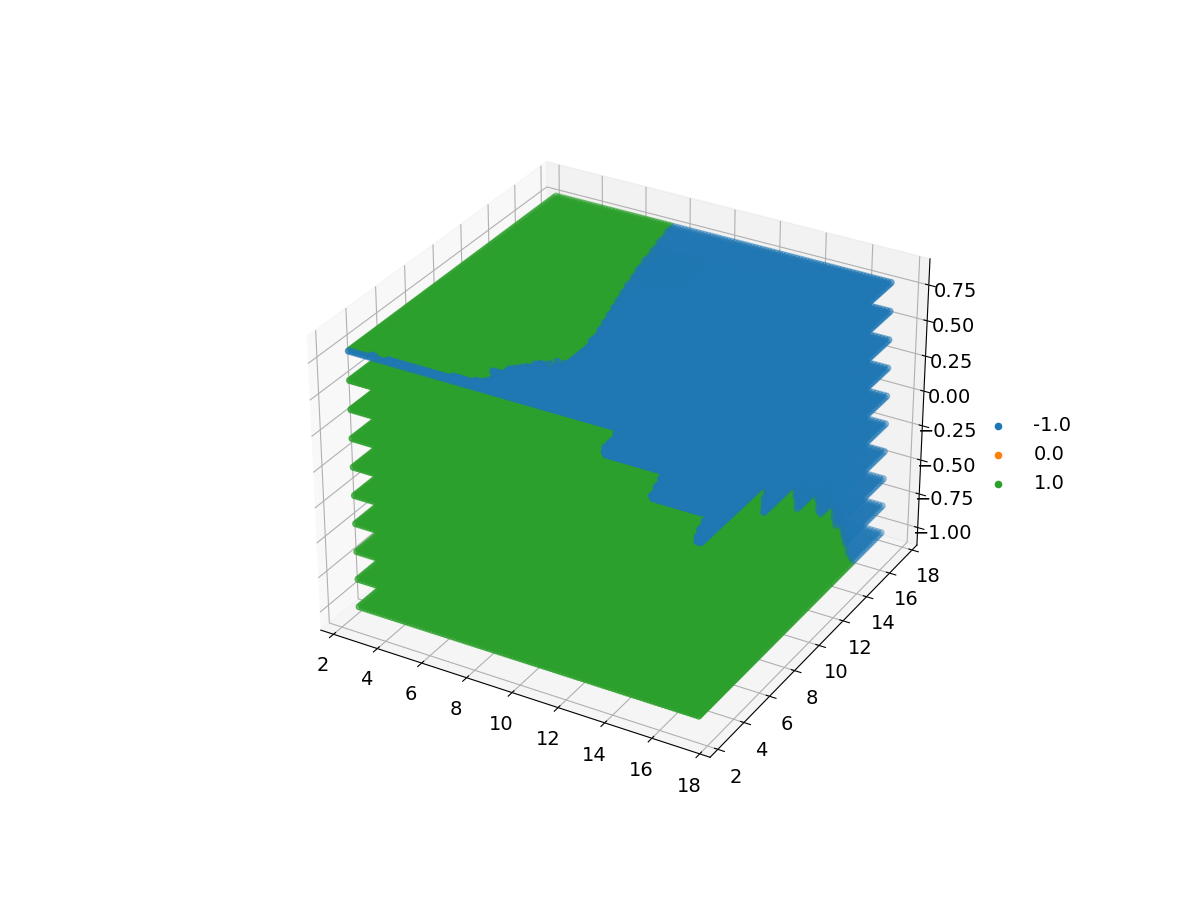

In [12]:
%matplotlib widget
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection='3d')
for grp_name, grp_idx in dataset_df.groupby('stability').groups.items():
    print(grp_name)
    y = dataset_df.iloc[grp_idx,2]
    x = dataset_df.iloc[grp_idx,1]
    z = dataset_df.iloc[grp_idx,0]
    c = dataset_df['stability']
    ax.scatter(x,y,z,label = grp_name, cmap = 'jet')

ax.legend(bbox_to_anchor=(1, 0.5), loc='center left', frameon=False)
plt.show()